In [1]:
import pandas as pd
import numpy as np
import re
import joblib
import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("balanced_mental_health_dataset.csv")

print("Shape:", df.shape)
print("\nLabel distribution:")
print(df["label"].value_counts())
print("\nMissing values:")
print(df.isnull().sum())
df.head(3)

Shape: (28518, 3)

Label distribution:
label
anxiety       5785
normal        5783
depression    5737
suicidal      5665
loneliness    5548
Name: count, dtype: int64

Missing values:
author    0
text      0
label     0
dtype: int64


,author,text,label
0,Comfortable-Fruit145,Im anxious about getting my girlfriend pregnan...,anxiety
1,Intelligent_Eye4486,Gagging when nervous/excited I’ve been gagging...,anxiety
2,mayalinko,Overwhelming fear of death. In a state of pani...,anxiety


In [3]:
def preprocess(text):
    text = str(text).lower()                          # lowercase
    text = re.sub(r"http\S+|www\S+", "", text)        # remove URLs
    text = re.sub(r"@\w+", "", text)                  # remove @mentions
    text = re.sub(r"[^a-z\s]", "", text)              # remove punctuation & numbers
    text = re.sub(r"\s+", " ", text).strip()          # collapse whitespace
    return text

df["clean_text"] = df["text"].apply(preprocess)

# Verify
print("Sample before:", df["text"].iloc[0])
print("Sample after: ", df["clean_text"].iloc[0])
print("\nAny empty strings after cleaning:", (df["clean_text"].str.strip() == "").sum())

Sample before: Im anxious about getting my girlfriend pregnant everything we have intercourse We use protection but that small percentage of pregnancy ("At a glance: condoms When used correctly every time you have sex, male condoms are 98% effective. This means 2 out of 100 people will become pregnant in 1 year when male condoms are used as contraception.") Always haunts me.
Sample after:  im anxious about getting my girlfriend pregnant everything we have intercourse we use protection but that small percentage of pregnancy at a glance condoms when used correctly every time you have sex male condoms are effective this means out of people will become pregnant in year when male condoms are used as contraception always haunts me

Any empty strings after cleaning: 12


In [4]:
# Drop the 12 empty rows
df = df[df["clean_text"].str.strip() != ""].reset_index(drop=True)
print("Shape after dropping empties:", df.shape)

# Encode labels to numbers
le = LabelEncoder()
df["label_enc"] = le.fit_transform(df["label"])

# Show the mapping
print("\nLabel encoding map:")
for i, cls in enumerate(le.classes_):
    print(f"  {i} → {cls}")

Shape after dropping empties: (28506, 4)

Label encoding map:
  0 → anxiety
  1 → depression
  2 → loneliness
  3 → normal
  4 → suicidal


In [5]:
X = df["clean_text"]
y = df["label_enc"]

# First split off test (15%)
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X, y, test_size=0.15, random_state=42, stratify=y
)

# Then split train and validation from the remainder (15% of total ≈ 17.6% of remainder)
X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val, test_size=0.176, random_state=42, stratify=y_train_val
)

print("Train size:     ", X_train.shape[0])
print("Validation size:", X_val.shape[0])
print("Test size:      ", X_test.shape[0])
print("\nTrain label distribution:")
print(pd.Series(y_train).value_counts().sort_index())

Train size:      19965
Validation size: 4265
Test size:       4276

Train label distribution:
label_enc
0    4051
1    4014
2    3884
3    4051
4    3965
Name: count, dtype: int64


In [6]:
tfidf = TfidfVectorizer(
    max_features=50000,      # top 50k words by frequency
    ngram_range=(1, 2),      # unigrams + bigrams ("feel hopeless" as one feature)
    min_df=2,                # ignore terms appearing in less than 2 documents
    sublinear_tf=True        # apply log normalization to term frequencies
)

# Fit ONLY on train, transform all three splits
X_train_tfidf = tfidf.fit_transform(X_train)
X_val_tfidf   = tfidf.transform(X_val)
X_test_tfidf  = tfidf.transform(X_test)

print("Train matrix shape:", X_train_tfidf.shape)
print("Val   matrix shape:", X_val_tfidf.shape)
print("Test  matrix shape:", X_test_tfidf.shape)
print("\nVocabulary size:", len(tfidf.vocabulary_))

Train matrix shape: (19965, 50000)
Val   matrix shape: (4265, 50000)
Test  matrix shape: (4276, 50000)

Vocabulary size: 50000


In [7]:
models = {
    "Logistic Regression": LogisticRegression(
        max_iter=1000, 
        C=5, 
        solver="lbfgs", 
        multi_class="multinomial",
        random_state=42
    ),
    "Linear SVM": LinearSVC(
        C=1.0, 
        max_iter=2000,
        random_state=42
    ),
    "Naive Bayes": MultinomialNB(
        alpha=0.1
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators=200, 
        max_depth=30, 
        random_state=42, 
        n_jobs=-1
    )
}

trained_models = {}

for name, model in models.items():
    print(f"Training {name}...", end=" ")
    model.fit(X_train_tfidf, y_train)
    trained_models[name] = model
    print("Done ✅")

Training Logistic Regression... Done ✅
Training Linear SVM... Done ✅
Training Naive Bayes... Done ✅
Training Random Forest... Done ✅


In [8]:
val_results = {}

for name, model in trained_models.items():
    y_pred = model.predict(X_val_tfidf)
    report = classification_report(y_val, y_pred, target_names=le.classes_, output_dict=True)
    val_results[name] = report
    print(f"\n{'='*50}")
    print(f"  {name}")
    print(f"{'='*50}")
    print(classification_report(y_val, y_pred, target_names=le.classes_))


  Logistic Regression
              precision    recall  f1-score   support

     anxiety       0.86      0.84      0.85       865
  depression       0.54      0.49      0.51       858
  loneliness       0.75      0.75      0.75       830
      normal       0.76      0.90      0.82       865
    suicidal       0.63      0.60      0.61       847

    accuracy                           0.71      4265
   macro avg       0.71      0.71      0.71      4265
weighted avg       0.71      0.71      0.71      4265


  Linear SVM
              precision    recall  f1-score   support

     anxiety       0.83      0.85      0.84       865
  depression       0.54      0.45      0.49       858
  loneliness       0.73      0.73      0.73       830
      normal       0.77      0.90      0.83       865
    suicidal       0.63      0.61      0.62       847

    accuracy                           0.71      4265
   macro avg       0.70      0.71      0.70      4265
weighted avg       0.70      0.71      0

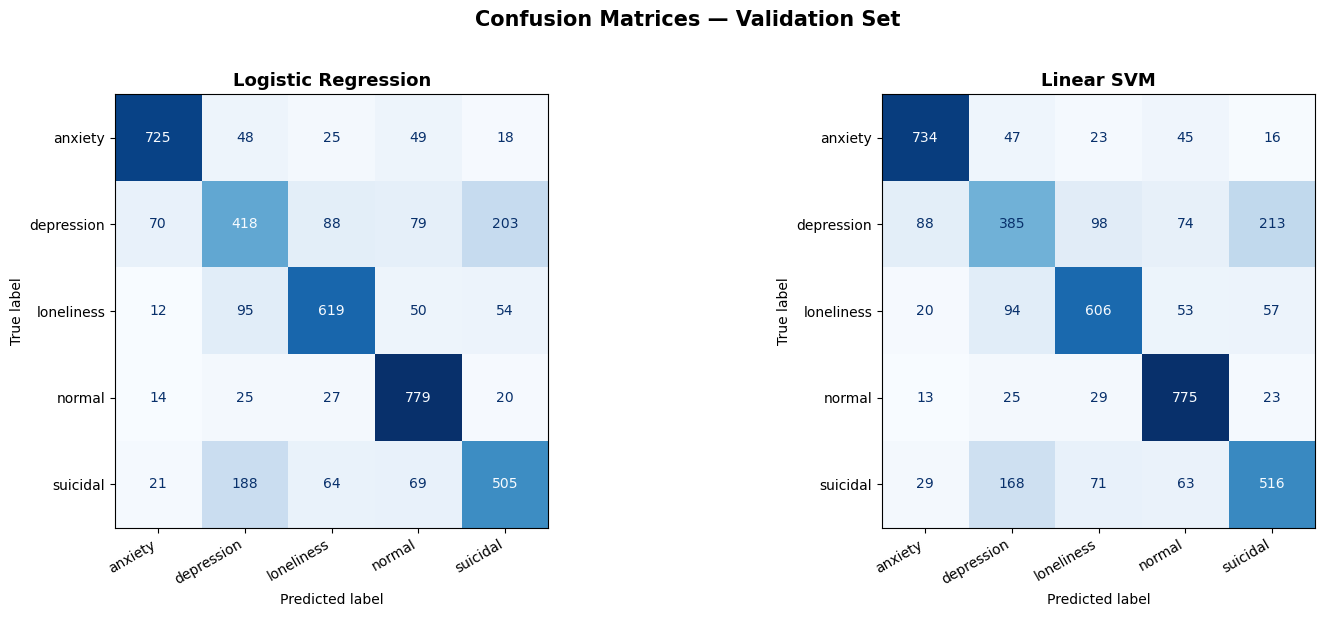

Saved as confusion_matrices.png


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, (name, model) in zip(axes, {
    "Logistic Regression": trained_models["Logistic Regression"],
    "Linear SVM":          trained_models["Linear SVM"]
}.items()):
    y_pred = model.predict(X_val_tfidf)
    cm = confusion_matrix(y_val, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
    disp.plot(ax=ax, colorbar=False, cmap="Blues")
    ax.set_title(f"{name}", fontsize=13, fontweight="bold")
    ax.set_xticklabels(le.classes_, rotation=30, ha="right")

plt.suptitle("Confusion Matrices — Validation Set", fontsize=15, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("confusion_matrices.png", bbox_inches="tight", dpi=150)
plt.show()
print("Saved as confusion_matrices.png")

  FINAL TEST SET RESULTS — Logistic Regression
              precision    recall  f1-score   support

     anxiety       0.86      0.84      0.85       868
  depression       0.57      0.53      0.55       860
  loneliness       0.76      0.72      0.74       832
      normal       0.77      0.90      0.83       867
    suicidal       0.64      0.63      0.64       849

    accuracy                           0.72      4276
   macro avg       0.72      0.72      0.72      4276
weighted avg       0.72      0.72      0.72      4276



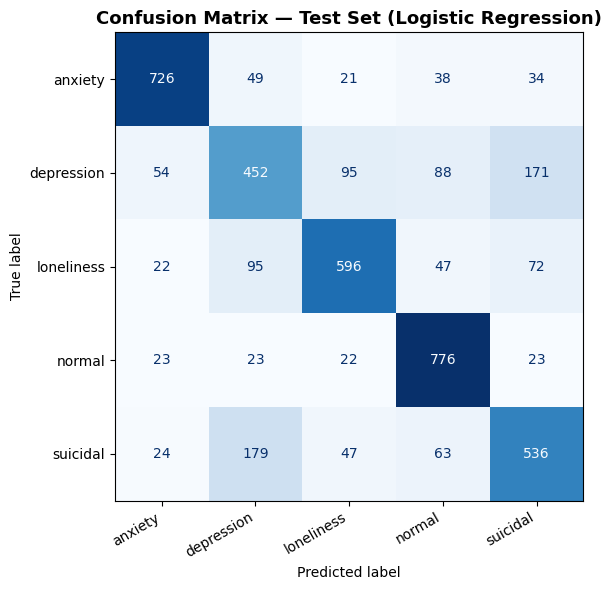

Saved as test_confusion_matrix.png


In [10]:
best_model = trained_models["Logistic Regression"]

y_test_pred = best_model.predict(X_test_tfidf)

print("=" * 50)
print("  FINAL TEST SET RESULTS — Logistic Regression")
print("=" * 50)
print(classification_report(y_test, y_test_pred, target_names=le.classes_))

# Confusion matrix on test set
fig, ax = plt.subplots(figsize=(8, 6))
cm = confusion_matrix(y_test, y_test_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
disp.plot(ax=ax, colorbar=False, cmap="Blues")
ax.set_title("Confusion Matrix — Test Set (Logistic Regression)", 
             fontsize=13, fontweight="bold")
ax.set_xticklabels(le.classes_, rotation=30, ha="right")
plt.tight_layout()
plt.savefig("test_confusion_matrix.png", bbox_inches="tight", dpi=150)
plt.show()
print("Saved as test_confusion_matrix.png")

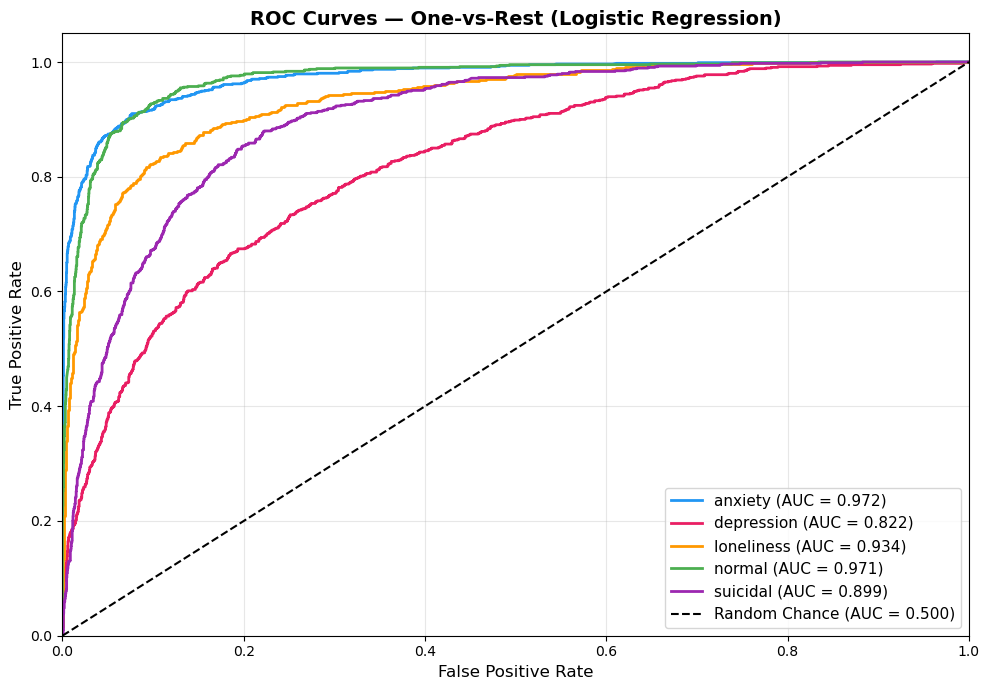

Saved as roc_curve.png


In [11]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc

# Binarize test labels for OvR
y_test_bin = label_binarize(y_test, classes=[0, 1, 2, 3, 4])

# Get probability scores
y_score = best_model.predict_proba(X_test_tfidf)

# Plot
fig, ax = plt.subplots(figsize=(10, 7))

colors = ["#2196F3", "#E91E63", "#FF9800", "#4CAF50", "#9C27B0"]

for i, (cls, color) in enumerate(zip(le.classes_, colors)):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    roc_auc = auc(fpr, tpr)
    ax.plot(fpr, tpr, color=color, lw=2,
            label=f"{cls} (AUC = {roc_auc:.3f})")

# Random chance baseline
ax.plot([0, 1], [0, 1], "k--", lw=1.5, label="Random Chance (AUC = 0.500)")

ax.set_xlim([0.0, 1.0])
ax.set_ylim([0.0, 1.05])
ax.set_xlabel("False Positive Rate", fontsize=12)
ax.set_ylabel("True Positive Rate", fontsize=12)
ax.set_title("ROC Curves — One-vs-Rest (Logistic Regression)", 
             fontsize=14, fontweight="bold")
ax.legend(loc="lower right", fontsize=11)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("roc_curve.png", bbox_inches="tight", dpi=150)
plt.show()
print("Saved as roc_curve.png")

In [12]:
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline

# Build a pipeline with TF-IDF + Logistic Regression together
pipeline = Pipeline([
    ("tfidf", TfidfVectorizer(sublinear_tf=True, ngram_range=(1, 2))),
    ("clf", LogisticRegression(max_iter=1000, solver="lbfgs", 
                               multi_class="multinomial", random_state=42))
])

# Parameter grid to search
param_grid = {
    "tfidf__max_features": [50000, 75000],
    "tfidf__min_df":       [1, 2],
    "clf__C":              [1, 5, 10]
}

grid_search = GridSearchCV(
    pipeline,
    param_grid,
    cv=3,                    # 3-fold cross validation
    scoring="f1_macro",      # optimize for macro F1
    n_jobs=-1,               # use all CPU cores
    verbose=1
)

# Fit on raw clean text — pipeline handles vectorization internally
grid_search.fit(X_train, y_train)

print("\nBest Parameters:", grid_search.best_params_)
print("Best CV Macro F1:", round(grid_search.best_score_, 4))

Fitting 3 folds for each of 12 candidates, totalling 36 fits

Best Parameters: {'clf__C': 5, 'tfidf__max_features': 75000, 'tfidf__min_df': 1}
Best CV Macro F1: 0.7027


In [13]:
tuned_model = grid_search.best_estimator_

y_pred_tuned = tuned_model.predict(X_test)

print("=" * 50)
print("  TUNED MODEL — Test Set Results")
print("=" * 50)
print(classification_report(y_test, y_pred_tuned, target_names=le.classes_))

# Compare before vs after tuning
original_f1 = 0.72
tuned_f1 = float(classification_report(
    y_test, y_pred_tuned, 
    target_names=le.classes_, 
    output_dict=True)["macro avg"]["f1-score"])

print(f"\nOriginal Macro F1 : {original_f1:.4f}")
print(f"Tuned Macro F1    : {tuned_f1:.4f}")
print(f"Improvement       : +{(tuned_f1 - original_f1):.4f}")

  TUNED MODEL — Test Set Results
              precision    recall  f1-score   support

     anxiety       0.85      0.83      0.84       868
  depression       0.57      0.52      0.54       860
  loneliness       0.77      0.72      0.74       832
      normal       0.76      0.90      0.82       867
    suicidal       0.64      0.63      0.64       849

    accuracy                           0.72      4276
   macro avg       0.72      0.72      0.72      4276
weighted avg       0.72      0.72      0.72      4276


Original Macro F1 : 0.7200
Tuned Macro F1    : 0.7171
Improvement       : +-0.0029


In [14]:
# Verify best_model is the original, not the tuned one
from sklearn.pipeline import Pipeline

print("Type of best_model:", type(best_model))
print("Type of tuned_model:", type(tuned_model))

# Check best_model's C value
print("\nbest_model C value:", best_model.C)

# Run predictions from both and compare F1
from sklearn.metrics import f1_score

pred_original = best_model.predict(X_test_tfidf)
pred_tuned    = tuned_model.predict(X_test)

f1_original = f1_score(y_test, pred_original, average="macro")
f1_tuned    = f1_score(y_test, pred_tuned, average="macro")

print(f"\nbest_model  Macro F1 : {f1_original:.4f}")
print(f"tuned_model Macro F1 : {f1_tuned:.4f}")
print(f"\n✅ Saving correct model: {'best_model' if f1_original >= f1_tuned else 'tuned_model'}")

Type of best_model: <class 'sklearn.linear_model._logistic.LogisticRegression'>
Type of tuned_model: <class 'sklearn.pipeline.Pipeline'>

best_model C value: 5

best_model  Macro F1 : 0.7184
tuned_model Macro F1 : 0.7171

✅ Saving correct model: best_model


In [15]:
import os

# Create a models folder
os.makedirs("models", exist_ok=True)

# Save the model and vectorizer separately
joblib.dump(best_model, "models/logistic_regression_model.pkl")
joblib.dump(tfidf, "models/tfidf_vectorizer.pkl")
joblib.dump(le, "models/label_encoder.pkl")

print("✅ Saved: models/logistic_regression_model.pkl")
print("✅ Saved: models/tfidf_vectorizer.pkl")
print("✅ Saved: models/label_encoder.pkl")

# Verify by reloading
loaded_model   = joblib.load("models/logistic_regression_model.pkl")
loaded_tfidf   = joblib.load("models/tfidf_vectorizer.pkl")
loaded_encoder = joblib.load("models/label_encoder.pkl")

# Quick sanity check on reload
test_sample = X_test.iloc[0]
original_pred = best_model.predict(tfidf.transform([test_sample]))[0]
reloaded_pred = loaded_model.predict(loaded_tfidf.transform([test_sample]))[0]

print("\n--- Reload Sanity Check ---")
print(f"Original prediction : {le.inverse_transform([original_pred])[0]}")
print(f"Reloaded prediction : {loaded_encoder.inverse_transform([reloaded_pred])[0]}")
print("Match:", original_pred == reloaded_pred)

✅ Saved: models/logistic_regression_model.pkl
✅ Saved: models/tfidf_vectorizer.pkl
✅ Saved: models/label_encoder.pkl

--- Reload Sanity Check ---
Original prediction : anxiety
Reloaded prediction : anxiety
Match: True


In [16]:
def predict_mental_health(text):
    # Preprocess
    cleaned = preprocess(text)
    
    if not cleaned.strip():
        return {"error": "Input text is empty after cleaning"}
    
    # Vectorize
    vectorized = tfidf.transform([cleaned])
    
    # Predict label
    pred_enc = best_model.predict(vectorized)[0]
    pred_label = le.inverse_transform([pred_enc])[0]
    
    # Confidence scores for all classes
    proba = best_model.predict_proba(vectorized)[0]
    confidence_scores = {
        cls: round(float(prob) * 100, 2)
        for cls, prob in zip(le.classes_, proba)
    }
    
    # Sort by confidence descending
    confidence_scores = dict(
        sorted(confidence_scores.items(), key=lambda x: x[1], reverse=True)
    )
    
    print(f"Input Text     : {text[:80]}{'...' if len(text) > 80 else ''}")
    print(f"Prediction     : {pred_label.upper()}")
    print(f"Confidence     : {confidence_scores[pred_label]}%")
    print(f"\nAll Scores:")
    for cls, score in confidence_scores.items():
        bar = "█" * int(score / 5)
        print(f"  {cls:<12} {score:>6.2f}%  {bar}")
    print("-" * 45)
    
    return {
        "prediction": pred_label,
        "confidence": confidence_scores[pred_label],
        "all_scores": confidence_scores
    }

# ---- Test it out ----
test_inputs = [
    "I feel so happy today, just had a great time with friends!",
    "I can't stop worrying about everything, my heart is always racing",
    "I have been feeling really down and hopeless for weeks now",
    "Nobody understands me, I feel completely alone in this world",
    "I don't see any point in living anymore, everything is falling apart"
]

print("=" * 45)
print("       MENTAL HEALTH TEXT CLASSIFIER")
print("=" * 45 + "\n")

for text in test_inputs:
    predict_mental_health(text)
    print()

       MENTAL HEALTH TEXT CLASSIFIER

Input Text     : I feel so happy today, just had a great time with friends!
Prediction     : LONELINESS
Confidence     : 47.44%

All Scores:
  loneliness    47.44%  █████████
  normal        24.90%  ████
  depression    21.62%  ████
  anxiety        3.26%  
  suicidal       2.78%  
---------------------------------------------

Input Text     : I can't stop worrying about everything, my heart is always racing
Prediction     : ANXIETY
Confidence     : 90.35%

All Scores:
  anxiety       90.35%  ██████████████████
  normal         4.77%  
  depression     2.36%  
  loneliness     1.63%  
  suicidal       0.89%  
---------------------------------------------

Input Text     : I have been feeling really down and hopeless for weeks now
Prediction     : DEPRESSION
Confidence     : 53.9%

All Scores:
  depression    53.90%  ██████████
  loneliness    12.93%  ██
  normal        12.87%  ██
  anxiety       10.44%  ██
  suicidal       9.86%  █
---------------

In [17]:
!pip install datasets

In [18]:
import datasets
print(datasets.__version__)

4.8.4


In [19]:
from datasets import load_dataset

# Load amazon polarity dataset — positive reviews only
print("Downloading Amazon reviews... (may take a minute)")
amazon = load_dataset("amazon_polarity", split="train", trust_remote_code=True)

# Convert to dataframe
amazon_df = amazon.to_pandas()
print("Downloaded:", amazon_df.shape)
print(amazon_df.head(3))

`trust_remote_code` is not supported anymore.
Please check that the Hugging Face dataset 'amazon_polarity' isn't based on a loading script and remove `trust_remote_code`.
If the dataset is based on a loading script, please ask the dataset author to remove it and convert it to a standard format like Parquet.


Downloaded: (3600000, 3)
   label                                  title  \
0      1         Stuning even for the non-gamer   
1      1  The best soundtrack ever to anything.   
2      1                               Amazing!   

                                             content  
0  This sound track was beautiful! It paints the ...  
1  I'm reading a lot of reviews saying that this ...  
2  This soundtrack is my favorite music of all ti...  


In [20]:
# Keep positive reviews only (label=1)
pos_reviews = amazon_df[amazon_df["label"] == 1].reset_index(drop=True)
print("Positive reviews:", pos_reviews.shape[0])

# Combine title + content for richer text
pos_reviews["text"] = (pos_reviews["title"] + " " + pos_reviews["content"])

# Apply same preprocessor we built earlier
pos_reviews["text"] = pos_reviews["text"].apply(preprocess)

# Filter out very short texts (less than 5 words)
pos_reviews = pos_reviews[pos_reviews["text"].str.split().str.len() >= 5].reset_index(drop=True)
print("After length filter:", pos_reviews.shape[0])

# Sample 3000 rows — we'll combine with synthetic for ~5800 total
amazon_normal = pos_reviews[["text"]].sample(n=3000, random_state=42).reset_index(drop=True)
print("Sampled:", amazon_normal.shape)
print("\nSample texts:")
for t in amazon_normal["text"].head(5).values:
    print(" →", t[:100])

Positive reviews: 1800000
After length filter: 1799972
Sampled: (3000, 1)

Sample texts:
 → great value thsi book was awesome i originally bought it for terry gooskind and robert jordan but fo
 → great product very happy with it it works very well as a voice recorder and an mp player the sound q
 → great as a dancer i pretty appreciate the select of great dancing and singing scenes i can recommend
 → if you like or dont like the movie you will like the music my name is jason i was three years old wh
 → it just rocks not one of the concept albumsbut great the cuts are powerfulso many songs added to the


In [21]:
# We already have 1.8M positive reviews — just sample 5800 directly
amazon_normal = pos_reviews[["text"]].sample(n=5800, random_state=42).reset_index(drop=True)

print("Normal data shape:", amazon_normal.shape)
print("\nSample texts:")
for t in amazon_normal["text"].head(5).values:
    print(" →", t[:100])

# Quick sanity check — make sure no mental health keywords sneak in
mental_health_keywords = ["suicide", "depress", "anxious", "lonely", "hopeless", "worthless"]
mask = amazon_normal["text"].str.contains("|".join(mental_health_keywords), case=False)
print(f"\nRows with mental health keywords: {mask.sum()} (removing these)")
amazon_normal = amazon_normal[~mask].reset_index(drop=True)
print("Final normal data shape:", amazon_normal.shape)

Normal data shape: (5800, 1)

Sample texts:
 → great value thsi book was awesome i originally bought it for terry gooskind and robert jordan but fo
 → great product very happy with it it works very well as a voice recorder and an mp player the sound q
 → great as a dancer i pretty appreciate the select of great dancing and singing scenes i can recommend
 → if you like or dont like the movie you will like the music my name is jason i was three years old wh
 → it just rocks not one of the concept albumsbut great the cuts are powerfulso many songs added to the

Rows with mental health keywords: 42 (removing these)
Final normal data shape: (5758, 1)


In [22]:
BAD = {"", "[removed]", "[deleted]", "nan", "none", "null"}

def clean_missing_like(s: pd.Series) -> pd.Series:
    s = s.astype(str).fillna("").str.strip()
    s = s.mask(s.str.lower().isin(BAD), "")
    return s

def standardize_text_only(df, label, text_col="text", author_col="author"):
    out = pd.DataFrame()
    out["author"] = df[author_col].astype(str).fillna("unknown") if author_col in df.columns else "unknown"
    out["text"] = clean_missing_like(df[text_col]) if text_col in df.columns else ""
    out["label"] = label
    out = out[out["text"].str.len() > 0].reset_index(drop=True)
    return out

def standardize_title_selftext(df, label, title_col="title", body_col="selftext", author_col="author"):
    out = pd.DataFrame()
    out["author"] = df[author_col].astype(str).fillna("unknown") if author_col in df.columns else "unknown"
    title = clean_missing_like(df[title_col]) if title_col in df.columns else ""
    body  = clean_missing_like(df[body_col])  if body_col in df.columns else ""
    out["text"] = (title + " " + body).str.replace(r"\s+", " ", regex=True).str.strip()
    out["label"] = label
    out = out[out["text"].str.len() > 0].reset_index(drop=True)
    return out

print("✅ Helper functions redefined")

✅ Helper functions redefined


In [23]:
# Build new normal_df in the same format as before
amazon_normal["author"] = ["normal_user_" + str(i) for i in range(len(amazon_normal))]
new_norm_df = standardize_text_only(amazon_normal, label="normal", text_col="text", author_col="author")

print("New normal class shape:", new_norm_df.shape)
print("\nSample:")
print(new_norm_df.head(3))

# Rebuild full dataset with new normal data
all_df_new = pd.concat([sw_df, anx_df, dep_df, lon_df, new_norm_df], ignore_index=True)
print("\nFull dataset shape:", all_df_new.shape)
print(all_df_new["label"].value_counts())

New normal class shape: (5758, 3)

Sample:
          author                                               text   label
0  normal_user_0  great value thsi book was awesome i originally...  normal
1  normal_user_1  great product very happy with it it works very...  normal
2  normal_user_2  great as a dancer i pretty appreciate the sele...  normal


NameError: name 'sw_df' is not defined

In [24]:
# Reload all raw CSVs and rebuild the class dataframes
sw      = pd.read_csv("swaug22.csv")
anx_raw = pd.read_csv("anxiaug22.csv")
dep_raw = pd.read_csv("depaug22.csv")
lon_raw = pd.read_csv("loneaug22.csv")

# Drop created_utc if present
for df_ in [sw, anx_raw, dep_raw, lon_raw]:
    if "created_utc" in df_.columns:
        df_.drop(columns=["created_utc"], inplace=True)

# Standardize all classes
sw_df  = standardize_title_selftext(sw,      label="suicidal",   title_col="title", body_col="selftext", author_col="author")
anx_df = standardize_title_selftext(anx_raw, label="anxiety",    title_col="title", body_col="selftext", author_col="author")
dep_df = standardize_title_selftext(dep_raw, label="depression", title_col="title", body_col="selftext", author_col="author")
lon_df = standardize_title_selftext(lon_raw, label="loneliness", title_col="title", body_col="selftext", author_col="author")

print("sw_df  :", sw_df.shape)
print("anx_df :", anx_df.shape)
print("dep_df :", dep_df.shape)
print("lon_df :", lon_df.shape)

# Now rebuild full dataset
all_df_new = pd.concat([sw_df, anx_df, dep_df, lon_df, new_norm_df], ignore_index=True)
print("\nFull dataset shape:", all_df_new.shape)
print(all_df_new["label"].value_counts())

sw_df  : (13480, 3)
anx_df : (7650, 3)
dep_df : (11991, 3)
lon_df : (5831, 3)

Full dataset shape: (44710, 3)
label
suicidal      13480
depression    11991
anxiety        7650
loneliness     5831
normal         5758
Name: count, dtype: int64


In [25]:
# Balance all classes to minimum count
min_n = all_df_new["label"].value_counts().min()
print("Balancing to:", min_n)

balanced_new = (all_df_new.groupby("label", group_keys=False)
                .apply(lambda x: x.sample(min_n, random_state=42))
                .reset_index(drop=True))

# Deduplicate
before = len(balanced_new)
balanced_new = balanced_new.drop_duplicates(subset=["text"]).reset_index(drop=True)
after = len(balanced_new)
print("Removed duplicates:", before - after)
print("Balanced shape:", balanced_new.shape)
print(balanced_new["label"].value_counts())

# Apply preprocessor
balanced_new["clean_text"] = balanced_new["text"].apply(preprocess)

# Drop empty texts
balanced_new = balanced_new[balanced_new["clean_text"].str.strip() != ""].reset_index(drop=True)
print("\nFinal shape after cleaning:", balanced_new.shape)

Balancing to: 5758
Removed duplicates: 577
Balanced shape: (28213, 3)
label
normal        5758
anxiety       5713
depression    5666
suicidal      5595
loneliness    5481
Name: count, dtype: int64

Final shape after cleaning: (28202, 4)


In [26]:
# Encode labels
le_new = LabelEncoder()
balanced_new["label_enc"] = le_new.fit_transform(balanced_new["label"])

print("Label mapping:")
for i, cls in enumerate(le_new.classes_):
    print(f"  {i} → {cls}")

# Split
X_new = balanced_new["clean_text"]
y_new = balanced_new["label_enc"]

X_train_new, X_test_new, y_train_new, y_test_new = train_test_split(
    X_new, y_new, test_size=0.15, random_state=42, stratify=y_new
)
X_train_new, X_val_new, y_train_new, y_val_new = train_test_split(
    X_train_new, y_train_new, test_size=0.176, random_state=42, stratify=y_train_new
)

print(f"\nTrain: {X_train_new.shape[0]} | Val: {X_val_new.shape[0]} | Test: {X_test_new.shape[0]}")

# Vectorize
tfidf_new = TfidfVectorizer(max_features=50000, ngram_range=(1, 2), min_df=2, sublinear_tf=True)
X_train_tfidf_new = tfidf_new.fit_transform(X_train_new)
X_val_tfidf_new   = tfidf_new.transform(X_val_new)
X_test_tfidf_new  = tfidf_new.transform(X_test_new)

print("TF-IDF shape:", X_train_tfidf_new.shape)

# Retrain Logistic Regression only (our best model)
print("\nTraining Logistic Regression...", end=" ")
lr_new = LogisticRegression(max_iter=1000, C=5, solver="lbfgs",
                             multi_class="multinomial", random_state=42)
lr_new.fit(X_train_tfidf_new, y_train_new)
print("Done ✅")

# Evaluate on validation
y_val_pred = lr_new.predict(X_val_tfidf_new)
print("\n--- Validation Results ---")
print(classification_report(y_val_new, y_val_pred, target_names=le_new.classes_))

Label mapping:
  0 → anxiety
  1 → depression
  2 → loneliness
  3 → normal
  4 → suicidal

Train: 19752 | Val: 4219 | Test: 4231
TF-IDF shape: (19752, 50000)

Training Logistic Regression... Done ✅

--- Validation Results ---
              precision    recall  f1-score   support

     anxiety       0.88      0.85      0.86       855
  depression       0.54      0.53      0.53       847
  loneliness       0.74      0.77      0.76       820
      normal       0.97      0.99      0.98       861
    suicidal       0.65      0.64      0.65       836

    accuracy                           0.76      4219
   macro avg       0.76      0.76      0.76      4219
weighted avg       0.76      0.76      0.76      4219



  FINAL TEST SET RESULTS — Improved Model
              precision    recall  f1-score   support

     anxiety       0.87      0.85      0.86       857
  depression       0.55      0.57      0.56       849
  loneliness       0.76      0.77      0.77       822
      normal       0.98      0.99      0.99       864
    suicidal       0.66      0.63      0.64       839

    accuracy                           0.77      4231
   macro avg       0.77      0.76      0.77      4231
weighted avg       0.77      0.77      0.77      4231

Old Model Macro F1 : 0.7184
New Model Macro F1 : 0.7651
Improvement        : +0.0467


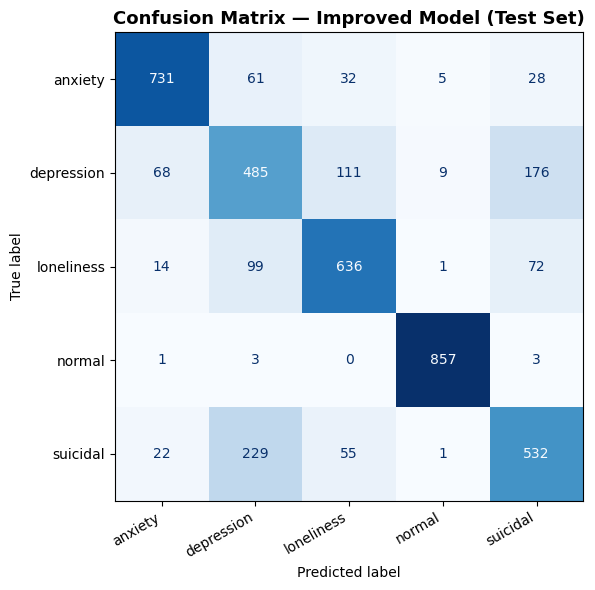

Saved as confusion_matrix_improved.png


In [27]:
# Evaluate on test set
y_test_pred_new = lr_new.predict(X_test_tfidf_new)

print("=" * 50)
print("  FINAL TEST SET RESULTS — Improved Model")
print("=" * 50)
print(classification_report(y_test_new, y_test_pred_new, target_names=le_new.classes_))

# Side by side macro F1 comparison
from sklearn.metrics import f1_score
old_f1 = 0.7184
new_f1 = f1_score(y_test_new, y_test_pred_new, average="macro")

print(f"Old Model Macro F1 : {old_f1:.4f}")
print(f"New Model Macro F1 : {new_f1:.4f}")
print(f"Improvement        : +{(new_f1 - old_f1):.4f}")

# Confusion matrix
fig, ax = plt.subplots(figsize=(8, 6))
cm = confusion_matrix(y_test_new, y_test_pred_new)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le_new.classes_)
disp.plot(ax=ax, colorbar=False, cmap="Blues")
ax.set_title("Confusion Matrix — Improved Model (Test Set)",
             fontsize=13, fontweight="bold")
ax.set_xticklabels(le_new.classes_, rotation=30, ha="right")
plt.tight_layout()
plt.savefig("confusion_matrix_improved.png", bbox_inches="tight", dpi=150)
plt.show()
print("Saved as confusion_matrix_improved.png")

In [28]:
import os
os.makedirs("models_v2", exist_ok=True)

joblib.dump(lr_new,      "models_v2/logistic_regression_model.pkl")
joblib.dump(tfidf_new,   "models_v2/tfidf_vectorizer.pkl")
joblib.dump(le_new,      "models_v2/label_encoder.pkl")

print("✅ Saved: models_v2/logistic_regression_model.pkl")
print("✅ Saved: models_v2/tfidf_vectorizer.pkl")
print("✅ Saved: models_v2/label_encoder.pkl")

# Reload and verify
loaded_model_v2   = joblib.load("models_v2/logistic_regression_model.pkl")
loaded_tfidf_v2   = joblib.load("models_v2/tfidf_vectorizer.pkl")
loaded_encoder_v2 = joblib.load("models_v2/label_encoder.pkl")

# Sanity check
sample = X_test_new.iloc[0]
pred_original = lr_new.predict(tfidf_new.transform([sample]))[0]
pred_reloaded = loaded_model_v2.predict(loaded_tfidf_v2.transform([sample]))[0]

print("\n--- Reload Sanity Check ---")
print(f"Original : {le_new.inverse_transform([pred_original])[0]}")
print(f"Reloaded : {loaded_encoder_v2.inverse_transform([pred_reloaded])[0]}")
print("Match:", pred_original == pred_reloaded)

✅ Saved: models_v2/logistic_regression_model.pkl
✅ Saved: models_v2/tfidf_vectorizer.pkl
✅ Saved: models_v2/label_encoder.pkl

--- Reload Sanity Check ---
Original : anxiety
Reloaded : anxiety
Match: True


In [29]:
def predict_mental_health(text):
    # Preprocess
    cleaned = preprocess(text)
    
    if not cleaned.strip():
        return {"error": "Input text is empty after cleaning"}
    
    # Vectorize
    vectorized = loaded_tfidf_v2.transform([cleaned])
    
    # Predict label
    pred_enc   = loaded_model_v2.predict(vectorized)[0]
    pred_label = loaded_encoder_v2.inverse_transform([pred_enc])[0]
    
    # Confidence scores for all classes
    proba = loaded_model_v2.predict_proba(vectorized)[0]
    confidence_scores = {
        cls: round(float(prob) * 100, 2)
        for cls, prob in zip(loaded_encoder_v2.classes_, proba)
    }
    
    # Sort by confidence descending
    confidence_scores = dict(
        sorted(confidence_scores.items(), key=lambda x: x[1], reverse=True)
    )
    
    print(f"Input Text : {text[:80]}{'...' if len(text) > 80 else ''}")
    print(f"Prediction : {pred_label.upper()}")
    print(f"Confidence : {confidence_scores[pred_label]}%")
    print(f"\nAll Scores:")
    for cls, score in confidence_scores.items():
        bar = "█" * int(score / 5)
        print(f"  {cls:<12} {score:>6.2f}%  {bar}")
    
    # Risk flag
    suicidal_score = confidence_scores.get("suicidal", 0)
    if suicidal_score > 30 and pred_label != "suicidal":
        print(f"\n  ⚠️  HIGH RISK FLAG: Suicidal score is {suicidal_score}% despite prediction being {pred_label}")
    
    print("-" * 45)
    return {
        "prediction": pred_label,
        "confidence": confidence_scores[pred_label],
        "all_scores": confidence_scores
    }

# ---- Test it out ----
test_inputs = [
    "I feel so happy today, just had a great time with friends!",
    "I can't stop worrying about everything, my heart is always racing",
    "I have been feeling really down and hopeless for weeks now",
    "Nobody understands me, I feel completely alone in this world",
    "I don't see any point in living anymore, everything is falling apart",
    "Just got back from a great vacation, feeling refreshed!"
]

print("=" * 45)
print("    MENTAL HEALTH TEXT CLASSIFIER v2")
print("=" * 45 + "\n")

for text in test_inputs:
    predict_mental_health(text)
    print()

    MENTAL HEALTH TEXT CLASSIFIER v2

Input Text : I feel so happy today, just had a great time with friends!
Prediction : LONELINESS
Confidence : 53.52%

All Scores:
  loneliness    53.52%  ██████████
  depression    34.78%  ██████
  suicidal       4.64%  
  normal         3.91%  
  anxiety        3.16%  
---------------------------------------------

Input Text : I can't stop worrying about everything, my heart is always racing
Prediction : ANXIETY
Confidence : 91.29%

All Scores:
  anxiety       91.29%  ██████████████████
  depression     4.19%  
  loneliness     2.89%  
  suicidal       1.09%  
  normal         0.54%  
---------------------------------------------

Input Text : I have been feeling really down and hopeless for weeks now
Prediction : DEPRESSION
Confidence : 76.17%

All Scores:
  depression    76.17%  ███████████████
  loneliness     8.63%  █
  anxiety        6.95%  █
  suicidal       5.77%  █
  normal         2.48%  
---------------------------------------------

Inp

In [30]:
# dair-ai/emotion contains Twitter text labeled with 
# sadness, joy, love, anger, fear, surprise
print("Downloading emotion dataset...")
emotion = load_dataset("dair-ai/emotion", split="train")
emotion_df = emotion.to_pandas()

print("Downloaded:", emotion_df.shape)
print("\nLabel distribution:")
print(emotion_df["label"].value_counts())
print("\nLabel mapping:")
print(emotion_df[["label"]].drop_duplicates())
print("\nSample:")
print(emotion_df.head(5))

Downloaded: (16000, 2)

Label distribution:
label
1    5362
0    4666
3    2159
4    1937
2    1304
5     572
Name: count, dtype: int64

Label mapping:
   label
0      0
2      3
3      2
6      5
7      4
8      1

Sample:
                                                text  label
0                            i didnt feel humiliated      0
1  i can go from feeling so hopeless to so damned...      0
2   im grabbing a minute to post i feel greedy wrong      3
3  i am ever feeling nostalgic about the fireplac...      2
4                               i am feeling grouchy      3


In [31]:
# Check which label numbers correspond to which emotions
# The emotion dataset uses these mappings:
# 0=sadness, 1=joy, 2=love, 3=anger, 4=fear, 5=surprise

label_map = {0: "sadness", 1: "joy", 2: "love", 3: "anger", 4: "fear", 5: "surprise"}
emotion_df["emotion"] = emotion_df["label"].map(label_map)

print("Emotion distribution:")
print(emotion_df["emotion"].value_counts())

print("\nSample JOY texts:")
joy_samples = emotion_df[emotion_df["emotion"] == "joy"]["text"].head(5)
for t in joy_samples:
    print(" →", t)

print("\nSample LOVE texts:")
love_samples = emotion_df[emotion_df["emotion"] == "love"]["text"].head(5)
for t in love_samples:
    print(" →", t)

Emotion distribution:
emotion
joy         5362
sadness     4666
anger       2159
fear        1937
love        1304
surprise     572
Name: count, dtype: int64

Sample JOY texts:
 → i have been with petronas for years i feel that petronas has performed well and made a huge profit
 → i do feel that running is a divine experience and that i can expect to have some type of spiritual encounter
 → i have immense sympathy with the general point but as a possible proto writer trying to find time to write in the corners of life and with no sign of an agent let alone a publishing contract this feels a little precious
 → i do not feel reassured anxiety is on each side
 → i have the feeling she was amused and delighted

Sample LOVE texts:
 → i am ever feeling nostalgic about the fireplace i will know that it is still on the property
 → i feel romantic too
 → i can t let go of that sad feeling that i want to be accepted here in this first home of mine
 → i ate i could feel a gentle tingle throughout

In [32]:
# Only keep joy and love labeled texts
positive_df = emotion_df[emotion_df["emotion"].isin(["joy", "love"])].reset_index(drop=True)
print("Before filtering:", positive_df.shape[0])

# Only keep texts with explicit positive keywords
positive_keywords = [
    "happy", "happiness", "excited", "wonderful", "amazing", "great",
    "fantastic", "joyful", "cheerful", "delighted", "love", "loved",
    "enjoy", "enjoyed", "fun", "blessed", "grateful", "thankful",
    "celebrate", "celebration", "smile", "laugh", "laughing", "pleased",
    "thrilled", "elated", "content", "proud", "peaceful", "relaxed"
]

pattern = "|".join(positive_keywords)
positive_df = positive_df[
    positive_df["text"].str.lower().str.contains(pattern)
].reset_index(drop=True)

print("After keyword filter:", positive_df.shape[0])
print("\nSample clean positive texts:")
for t in positive_df["text"].sample(8, random_state=42).values:
    print(" →", t)

Before filtering: 6666
After keyword filter: 1629

Sample clean positive texts:
 → im feeling very blessed to live in a state with such beautiful sights like virginia has
 → i murakami but the first that i feel captures what makes him so beloved by his fans
 → i cant even remember what it feels like to be loved
 → i am feeling a combination of smug and happy
 → i am feeling extremely pleased with myself and i decide to give the guy another rupees
 → i want to be in the future years some of you made me feel amazing and some of you are the best friends i could ever ask for
 → i can see a dramatic improvement in my skills on the dubied already and feel that with practice i could produce lovely work in the future
 → i feel so incredibly blessed especially during the hectic exam period


In [33]:
negative_keywords = [
    "sad", "depress", "anxious", "anxiety", "lonely", "alone", "hopeless",
    "worthless", "hurt", "pain", "cry", "crying", "tears", "fear", "scared",
    "angry", "hate", "terrible", "horrible", "awful", "miserable", "suffer",
    "cant remember", "never felt", "used to feel", "miss", "lost", "empty",
    "tired", "exhausted", "overwhelm", "stress", "worried", "cant", "can't"
]

neg_pattern = "|".join(negative_keywords)
clean_positive = positive_df[
    ~positive_df["text"].str.lower().str.contains(neg_pattern)
].reset_index(drop=True)

print("After removing negatives:", clean_positive.shape[0])
print("\nSample texts:")
for t in clean_positive["text"].sample(8, random_state=42).values:
    print(" →", t)

After removing negatives: 1498

Sample texts:
 → i know that i love what i do but struggle with feeling content and balanced
 → i am feeling more pleased over this light fixture thing than i was
 → i feel peaceful it s ok
 → i wanted to because he loves me and i feel like if he cares enough about me even if he doesnt care about the wedding itself he should be more supportive and not throw it in my face
 → i did feel a connection between the two of them i wasn t convinced they d made it to the love stage yet
 → i am on the write track i feel contented and at peace
 → i left sizzler feeling contented
 → i think they enjoyed the event because it made them feel welcomed


In [34]:
# Prepare emotion texts
emotion_normal = clean_positive[["text"]].copy()
emotion_normal["text"] = emotion_normal["text"].apply(preprocess)
emotion_normal = emotion_normal[
    emotion_normal["text"].str.split().str.len() >= 5
].reset_index(drop=True)

# Take 3000 from amazon reviews
amazon_sample = pos_reviews[["text"]].sample(n=3000, random_state=99).reset_index(drop=True)

# Remove mental health keywords from amazon sample
mask = amazon_sample["text"].str.contains(
    "|".join(["suicide", "depress", "anxious", "lonely", "hopeless", "worthless"]),
    case=False
)
amazon_sample = amazon_sample[~mask].reset_index(drop=True)
print("Amazon sample after cleaning:", amazon_sample.shape[0])

# Combine both sources
combined_normal = pd.concat([amazon_sample, emotion_normal], ignore_index=True)
combined_normal = combined_normal.drop_duplicates(subset=["text"]).reset_index(drop=True)
combined_normal["author"] = ["normal_user_" + str(i) for i in range(len(combined_normal))]

print("Emotion texts:", emotion_normal.shape[0])
print("Amazon texts :", amazon_sample.shape[0])
print("Combined     :", combined_normal.shape[0])

print("\nSample from combined:")
for t in combined_normal.sample(6, random_state=42)["text"].values:
    print(" →", t[:100])

Amazon sample after cleaning: 2977
Emotion texts: 1479
Amazon texts : 2977
Combined     : 4455

Sample from combined:
 → great look satisfied with the product looks beautiful nice picture quality good sound memory card re
 → a highly readable history of the civil war in telling the stories of lee and grant smith is really w
 → fun childrens book purchased for my son to read to his soontoarrive child it was my sons favorite bo
 → just what the doctor ordered my youngest daughter in college seems very well pleased with this selec
 → i feel his love and blessings as i meet loving supportive people as im inspired to write new songs a
 → i do not believe all media content is bad in fact much of it i feel is absolutly vital to human flou


In [35]:
# Build final normal_df
new_norm_df_v2 = standardize_text_only(combined_normal, label="normal", 
                                        text_col="text", author_col="author")
print("Final normal class:", new_norm_df_v2.shape)

# Rebuild full dataset
all_df_v2 = pd.concat([sw_df, anx_df, dep_df, lon_df, new_norm_df_v2], ignore_index=True)
print("\nFull dataset shape:", all_df_v2.shape)
print(all_df_v2["label"].value_counts())

# Balance to minimum class size
min_n = all_df_v2["label"].value_counts().min()
print("\nBalancing to:", min_n)

balanced_v2 = (all_df_v2.groupby("label", group_keys=False)
               .apply(lambda x: x.sample(min_n, random_state=42))
               .reset_index(drop=True))

# Deduplicate
before = len(balanced_v2)
balanced_v2 = balanced_v2.drop_duplicates(subset=["text"]).reset_index(drop=True)
print("Removed duplicates:", before - len(balanced_v2))

# Preprocess
balanced_v2["clean_text"] = balanced_v2["text"].apply(preprocess)
balanced_v2 = balanced_v2[balanced_v2["clean_text"].str.strip() != ""].reset_index(drop=True)
print("Final shape:", balanced_v2.shape)

# Encode labels
le_v2 = LabelEncoder()
balanced_v2["label_enc"] = le_v2.fit_transform(balanced_v2["label"])

# Split
X_v2 = balanced_v2["clean_text"]
y_v2 = balanced_v2["label_enc"]

X_train_v2, X_test_v2, y_train_v2, y_test_v2 = train_test_split(
    X_v2, y_v2, test_size=0.15, random_state=42, stratify=y_v2
)
X_train_v2, X_val_v2, y_train_v2, y_val_v2 = train_test_split(
    X_train_v2, y_train_v2, test_size=0.176, random_state=42, stratify=y_train_v2
)

print(f"\nTrain: {X_train_v2.shape[0]} | Val: {X_val_v2.shape[0]} | Test: {X_test_v2.shape[0]}")

# Vectorize
tfidf_v2 = TfidfVectorizer(max_features=50000, ngram_range=(1, 2), 
                            min_df=2, sublinear_tf=True)
X_train_tfidf_v2 = tfidf_v2.fit_transform(X_train_v2)
X_val_tfidf_v2   = tfidf_v2.transform(X_val_v2)
X_test_tfidf_v2  = tfidf_v2.transform(X_test_v2)

# Train
print("\nTraining Logistic Regression...", end=" ")
lr_v2 = LogisticRegression(max_iter=1000, C=5, solver="lbfgs",
                            multi_class="multinomial", random_state=42)
lr_v2.fit(X_train_tfidf_v2, y_train_v2)
print("Done ✅")

# Evaluate on validation
y_val_pred_v2 = lr_v2.predict(X_val_tfidf_v2)
print("\n--- Validation Results ---")
print(classification_report(y_val_v2, y_val_pred_v2, target_names=le_v2.classes_))

Final normal class: (4455, 3)

Full dataset shape: (43407, 3)
label
suicidal      13480
depression    11991
anxiety        7650
loneliness     5831
normal         4455
Name: count, dtype: int64

Balancing to: 4455
Removed duplicates: 387
Final shape: (21880, 4)

Train: 15324 | Val: 3274 | Test: 3282

Training Logistic Regression... Done ✅

--- Validation Results ---
              precision    recall  f1-score   support

     anxiety       0.85      0.85      0.85       662
  depression       0.55      0.52      0.54       658
  loneliness       0.74      0.77      0.76       638
      normal       0.93      0.97      0.95       667
    suicidal       0.64      0.62      0.63       649

    accuracy                           0.75      3274
   macro avg       0.74      0.75      0.75      3274
weighted avg       0.74      0.75      0.75      3274



In [36]:
def quick_predict(text):
    cleaned = preprocess(text)
    vectorized = tfidf_v2.transform([cleaned])
    pred_enc = lr_v2.predict(vectorized)[0]
    pred_label = le_v2.inverse_transform([pred_enc])[0]
    proba = lr_v2.predict_proba(vectorized)[0]
    confidence_scores = {
        cls: round(float(prob) * 100, 2)
        for cls, prob in zip(le_v2.classes_, proba)
    }
    confidence_scores = dict(
        sorted(confidence_scores.items(), key=lambda x: x[1], reverse=True)
    )
    print(f"Input      : {text[:70]}{'...' if len(text) > 70 else ''}")
    print(f"Prediction : {pred_label.upper()} ({confidence_scores[pred_label]}%)")
    for cls, score in confidence_scores.items():
        bar = "█" * int(score / 5)
        print(f"  {cls:<12} {score:>6.2f}%  {bar}")
    print("-" * 45)

test_inputs = [
    "I feel so happy today, just had a great time with friends!",
    "Just got back from a great vacation, feeling refreshed!",
    "I can't stop worrying about everything, my heart is always racing",
    "I have been feeling really down and hopeless for weeks now",
    "Nobody understands me, I feel completely alone in this world",
    "I don't see any point in living anymore, everything is falling apart",
    "Had a wonderful dinner with family tonight, feeling blessed!",
    "I love my new job, everything is going so well lately"
]

print("=" * 45)
print("    MODEL V3 PREDICTION TEST")
print("=" * 45 + "\n")

for text in test_inputs:
    quick_predict(text)
    print()

    MODEL V3 PREDICTION TEST

Input      : I feel so happy today, just had a great time with friends!
Prediction : NORMAL (86.88%)
  normal        86.88%  █████████████████
  loneliness     7.55%  █
  depression     2.70%  
  anxiety        1.45%  
  suicidal       1.41%  
---------------------------------------------

Input      : Just got back from a great vacation, feeling refreshed!
Prediction : NORMAL (73.41%)
  normal        73.41%  ██████████████
  depression    15.01%  ███
  loneliness     5.09%  █
  anxiety        4.56%  
  suicidal       1.93%  
---------------------------------------------

Input      : I can't stop worrying about everything, my heart is always racing
Prediction : ANXIETY (87.46%)
  anxiety       87.46%  █████████████████
  depression     5.51%  █
  suicidal       3.06%  
  loneliness     2.80%  
  normal         1.16%  
---------------------------------------------

Input      : I have been feeling really down and hopeless for weeks now
Prediction : DEPRESS

  FINAL TEST SET RESULTS — Model V3
              precision    recall  f1-score   support

     anxiety       0.87      0.85      0.86       664
  depression       0.57      0.56      0.56       659
  loneliness       0.76      0.76      0.76       640
      normal       0.93      0.98      0.96       668
    suicidal       0.63      0.63      0.63       651

    accuracy                           0.76      3282
   macro avg       0.75      0.76      0.75      3282
weighted avg       0.75      0.76      0.76      3282


--- Model Comparison ---
V1 (original)     Macro F1: 0.7184
V2 (amazon only)  Macro F1: 0.7651
V3 (amazon+emotion) Macro F1: 0.7547


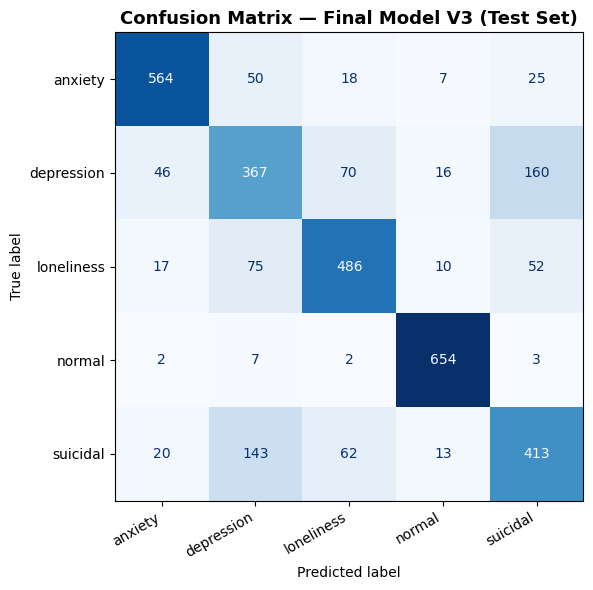


Saved as confusion_matrix_v3.png


In [37]:
# Evaluate on test set
y_test_pred_v2 = lr_v2.predict(X_test_tfidf_v2)

print("=" * 50)
print("  FINAL TEST SET RESULTS — Model V3")
print("=" * 50)
print(classification_report(y_test_v2, y_test_pred_v2, target_names=le_v2.classes_))

# Compare all three models
print("\n--- Model Comparison ---")
print(f"V1 (original)     Macro F1: 0.7184")
print(f"V2 (amazon only)  Macro F1: 0.7651")
v3_f1 = f1_score(y_test_v2, y_test_pred_v2, average="macro")
print(f"V3 (amazon+emotion) Macro F1: {v3_f1:.4f}")

# Confusion matrix
fig, ax = plt.subplots(figsize=(8, 6))
cm = confusion_matrix(y_test_v2, y_test_pred_v2)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le_v2.classes_)
disp.plot(ax=ax, colorbar=False, cmap="Blues")
ax.set_title("Confusion Matrix — Final Model V3 (Test Set)",
             fontsize=13, fontweight="bold")
ax.set_xticklabels(le_v2.classes_, rotation=30, ha="right")
plt.tight_layout()
plt.savefig("confusion_matrix_v3.png", bbox_inches="tight", dpi=150)
plt.show()
print("\nSaved as confusion_matrix_v3.png")

In [38]:
os.makedirs("models_v3", exist_ok=True)

joblib.dump(lr_v2,    "models_v3/logistic_regression_model.pkl")
joblib.dump(tfidf_v2, "models_v3/tfidf_vectorizer.pkl")
joblib.dump(le_v2,    "models_v3/label_encoder.pkl")

print("✅ Saved: models_v3/logistic_regression_model.pkl")
print("✅ Saved: models_v3/tfidf_vectorizer.pkl")
print("✅ Saved: models_v3/label_encoder.pkl")

# Reload and verify
loaded_model_v3   = joblib.load("models_v3/logistic_regression_model.pkl")
loaded_tfidf_v3   = joblib.load("models_v3/tfidf_vectorizer.pkl")
loaded_encoder_v3 = joblib.load("models_v3/label_encoder.pkl")

# Sanity check
sample = X_test_v2.iloc[0]
pred_original = lr_v2.predict(tfidf_v2.transform([sample]))[0]
pred_reloaded = loaded_model_v3.predict(loaded_tfidf_v3.transform([sample]))[0]

print("\n--- Reload Sanity Check ---")
print(f"Original : {le_v2.inverse_transform([pred_original])[0]}")
print(f"Reloaded : {loaded_encoder_v3.inverse_transform([pred_reloaded])[0]}")
print("Match    :", pred_original == pred_reloaded)

✅ Saved: models_v3/logistic_regression_model.pkl
✅ Saved: models_v3/tfidf_vectorizer.pkl
✅ Saved: models_v3/label_encoder.pkl

--- Reload Sanity Check ---
Original : anxiety
Reloaded : anxiety
Match    : True


In [39]:
def predict_mental_health(text):
    # Preprocess
    cleaned = preprocess(text)
    
    if not cleaned.strip():
        return {"error": "Input text is empty after cleaning"}
    
    # Vectorize + Predict
    vectorized  = loaded_tfidf_v3.transform([cleaned])
    pred_enc    = loaded_model_v3.predict(vectorized)[0]
    pred_label  = loaded_encoder_v3.inverse_transform([pred_enc])[0]
    proba       = loaded_model_v3.predict_proba(vectorized)[0]
    
    # Confidence scores
    confidence_scores = {
        cls: round(float(prob) * 100, 2)
        for cls, prob in zip(loaded_encoder_v3.classes_, proba)
    }
    confidence_scores = dict(
        sorted(confidence_scores.items(), key=lambda x: x[1], reverse=True)
    )
    
    # Risk flag — suicidal score > 30% regardless of top prediction
    suicidal_score = confidence_scores.get("suicidal", 0)
    risk_flag = suicidal_score > 30 and pred_label != "suicidal"
    
    # Display
    print(f"Input      : {text[:75]}{'...' if len(text) > 75 else ''}")
    print(f"Prediction : {pred_label.upper()}")
    print(f"Confidence : {confidence_scores[pred_label]}%")
    print(f"\nAll Scores:")
    for cls, score in confidence_scores.items():
        bar = "█" * int(score / 5)
        marker = " ◄" if cls == pred_label else ""
        print(f"  {cls:<12} {score:>6.2f}%  {bar}{marker}")
    if risk_flag:
        print(f"\n  ⚠️  HIGH RISK FLAG: Suicidal score {suicidal_score}%")
    print("-" * 48)
    
    return {
        "prediction"  : pred_label,
        "confidence"  : confidence_scores[pred_label],
        "all_scores"  : confidence_scores,
        "risk_flag"   : risk_flag
    }

# ---- Final Test ----
test_inputs = [
    "I feel so happy today, just had a great time with friends!",
    "Just got back from a great vacation, feeling refreshed!",
    "I had a wonderful dinner with family tonight, feeling blessed",
    "I can't stop worrying about everything, my heart is always racing",
    "I have been feeling really down and hopeless for weeks now",
    "Nobody understands me, I feel completely alone in this world",
    "I don't see any point in living anymore, everything is falling apart",
    "I haven't left my bed in days, nothing feels worth doing anymore"
]

print("=" * 48)
print("    MENTAL HEALTH CLASSIFIER — FINAL MODEL")
print("=" * 48 + "\n")

for text in test_inputs:
    predict_mental_health(text)
    print()

    MENTAL HEALTH CLASSIFIER — FINAL MODEL

Input      : I feel so happy today, just had a great time with friends!
Prediction : NORMAL
Confidence : 86.88%

All Scores:
  normal        86.88%  █████████████████ ◄
  loneliness     7.55%  █
  depression     2.70%  
  anxiety        1.45%  
  suicidal       1.41%  
------------------------------------------------

Input      : Just got back from a great vacation, feeling refreshed!
Prediction : NORMAL
Confidence : 73.41%

All Scores:
  normal        73.41%  ██████████████ ◄
  depression    15.01%  ███
  loneliness     5.09%  █
  anxiety        4.56%  
  suicidal       1.93%  
------------------------------------------------

Input      : I had a wonderful dinner with family tonight, feeling blessed
Prediction : NORMAL
Confidence : 94.17%

All Scores:
  normal        94.17%  ██████████████████ ◄
  suicidal       2.70%  
  loneliness     1.21%  
  depression     1.13%  
  anxiety        0.79%  
----------------------------------------------

In [40]:
import joblib
import pandas as pd

# Save the preprocessed splits so new notebook can use them directly
# without reprocessing everything from scratch
joblib.dump(X_train_v2.values, "models_v3/X_train.pkl")
joblib.dump(X_val_v2.values,   "models_v3/X_val.pkl")
joblib.dump(X_test_v2.values,  "models_v3/X_test.pkl")
joblib.dump(y_train_v2.values, "models_v3/y_train.pkl")
joblib.dump(y_val_v2.values,   "models_v3/y_val.pkl")
joblib.dump(y_test_v2.values,  "models_v3/y_test.pkl")

# Save label classes separately for easy access
joblib.dump(le_v2.classes_, "models_v3/label_classes.pkl")

# Save the full balanced dataset too
balanced_v2.to_csv("models_v3/balanced_v2.csv", index=False)

print("✅ X_train, X_val, X_test saved")
print("✅ y_train, y_val, y_test saved")
print("✅ label_classes saved")
print("✅ balanced_v2.csv saved")
print("\nAll files in models_v3/:")
import os
for f in os.listdir("models_v3"):
    size = os.path.getsize(f"models_v3/{f}") / (1024*1024)
    print(f"  {f:<40} {size:.2f} MB")

✅ X_train, X_val, X_test saved
✅ y_train, y_val, y_test saved
✅ label_classes saved
✅ balanced_v2.csv saved

All files in models_v3/:
  balanced_v2.csv                          26.02 MB
  label_classes.pkl                        0.00 MB
  label_encoder.pkl                        0.00 MB
  logistic_regression_model.pkl            1.91 MB
  tfidf_vectorizer.pkl                     1.88 MB
  X_test.pkl                               1.89 MB
  X_train.pkl                              8.79 MB
  X_val.pkl                                1.87 MB
  y_test.pkl                               0.03 MB
  y_train.pkl                              0.12 MB
  y_val.pkl                                0.03 MB


In [1]:
import joblib
import sklearn
print("sklearn version:", sklearn.__version__)

# Reload existing models
lr      = joblib.load("models_v3/logistic_regression_model.pkl")
tfidf   = joblib.load("models_v3/tfidf_vectorizer.pkl")
encoder = joblib.load("models_v3/label_encoder.pkl")

# Re-save with protocol 4 (more compatible)
joblib.dump(lr,      "models_v3/logistic_regression_model.pkl", protocol=4)
joblib.dump(tfidf,   "models_v3/tfidf_vectorizer.pkl",          protocol=4)
joblib.dump(encoder, "models_v3/label_encoder.pkl",             protocol=4)

print("✅ Models re-saved with protocol 4")
print("sklearn version saved:", sklearn.__version__)

sklearn version: 1.7.2
✅ Models re-saved with protocol 4
sklearn version saved: 1.7.2


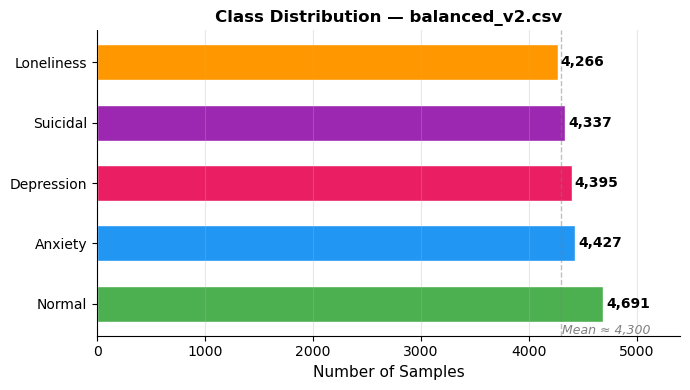

Saved: fig1_class_distribution.png


In [1]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

labels = ['Normal', 'Anxiety', 'Depression', 'Suicidal', 'Loneliness']
counts = [4691, 4427, 4395, 4337, 4266]
colors = ['#4CAF50', '#2196F3', '#E91E63', '#9C27B0', '#FF9800']

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.barh(labels, counts, color=colors, edgecolor='white', height=0.6)

# Value labels on each bar
for bar, count in zip(bars, counts):
    ax.text(bar.get_width() + 30, bar.get_y() + bar.get_height()/2,
            f'{count:,}', va='center', ha='left', fontsize=10, fontweight='bold')

ax.set_xlabel('Number of Samples', fontsize=11)
ax.set_title('Class Distribution — balanced_v2.csv', fontsize=12, fontweight='bold')
ax.set_xlim(0, 5400)
ax.axvline(x=4300, color='gray', linestyle='--', alpha=0.5, linewidth=1)
ax.text(4310, -0.5, 'Mean ≈ 4,300', color='gray', fontsize=9, style='italic')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig('fig1_class_distribution.png', dpi=300, bbox_inches='tight')
plt.show()
print("Saved: fig1_class_distribution.png")

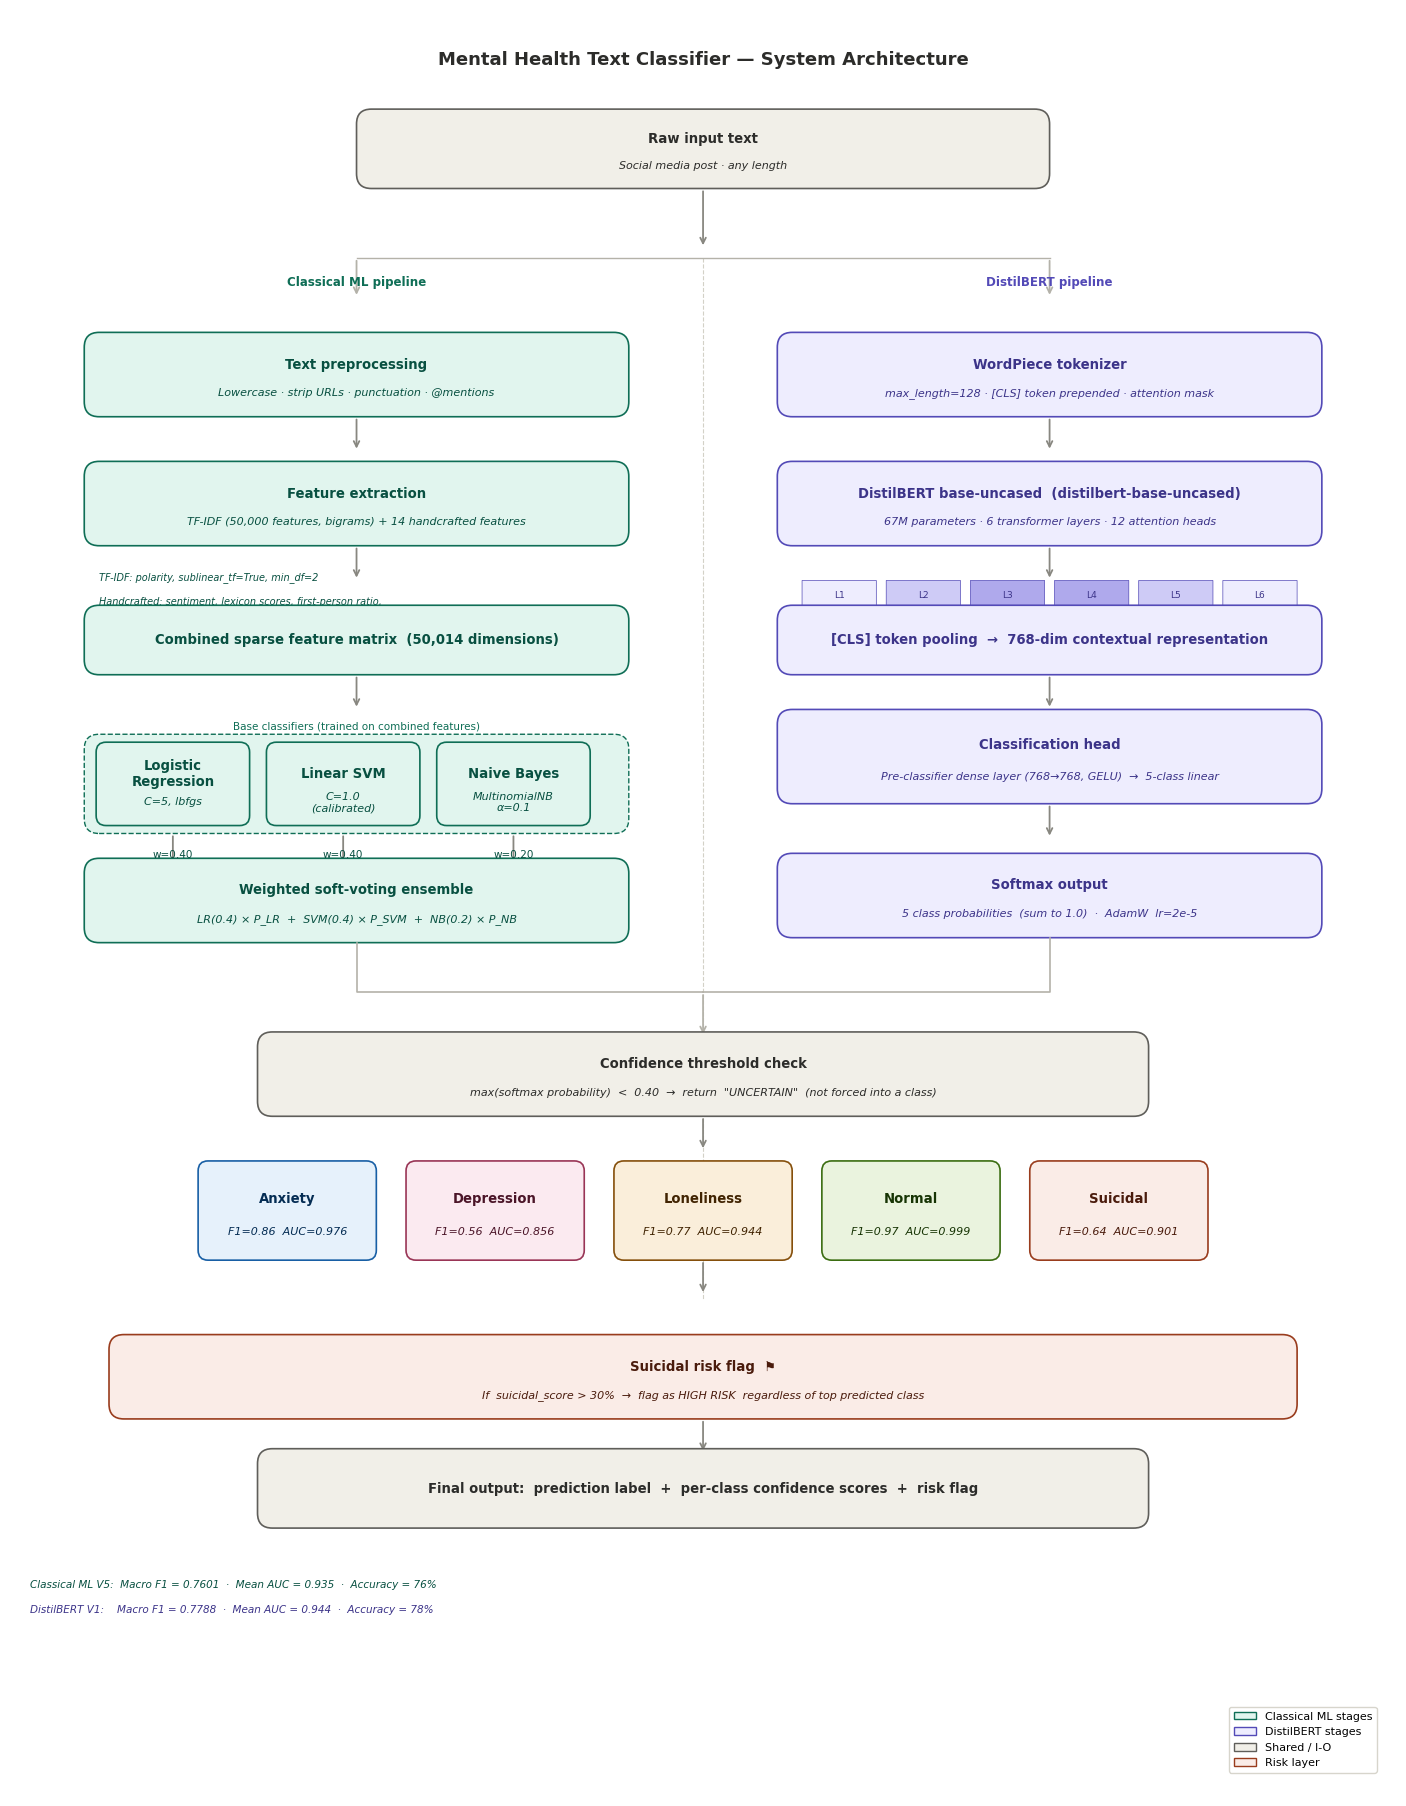

Saved: architecture_diagram.png


In [1]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch
import matplotlib.patheffects as pe

fig, ax = plt.subplots(1, 1, figsize=(14, 18))
ax.set_xlim(0, 14)
ax.set_ylim(0, 18)
ax.axis('off')
fig.patch.set_facecolor('white')

# ── COLOR PALETTE ────────────────────────────────────────────────
C_TEAL_FILL   = '#E1F5EE'
C_TEAL_EDGE   = '#0F6E56'
C_TEAL_TEXT   = '#085041'

C_PURPLE_FILL = '#EEEDFE'
C_PURPLE_EDGE = '#534AB7'
C_PURPLE_TEXT = '#3C3489'

C_GRAY_FILL   = '#F1EFE8'
C_GRAY_EDGE   = '#5F5E5A'
C_GRAY_TEXT   = '#2C2C2A'

C_AMBER_FILL  = '#FAEEDA'
C_AMBER_EDGE  = '#854F0B'
C_AMBER_TEXT  = '#412402'

C_CORAL_FILL  = '#FAECE7'
C_CORAL_EDGE  = '#993C1D'
C_CORAL_TEXT  = '#4A1B0C'

C_GREEN_FILL  = '#EAF3DE'
C_GREEN_EDGE  = '#3B6D11'
C_GREEN_TEXT  = '#173404'

C_BLUE_FILL   = '#E6F1FB'
C_BLUE_EDGE   = '#185FA5'
C_BLUE_TEXT   = '#042C53'

C_PINK_FILL   = '#FBEAF0'
C_PINK_EDGE   = '#993556'
C_PINK_TEXT   = '#4B1528'

# ── HELPER FUNCTIONS ─────────────────────────────────────────────
def box(ax, x, y, w, h, title, subtitle=None,
        fill=C_GRAY_FILL, edge=C_GRAY_EDGE, tc=C_GRAY_TEXT, r=0.15):
    rect = FancyBboxPatch((x, y), w, h,
                          boxstyle=f"round,pad=0,rounding_size={r}",
                          facecolor=fill, edgecolor=edge, linewidth=1.2, zorder=3)
    ax.add_patch(rect)
    if subtitle:
        ax.text(x + w/2, y + h*0.62, title,
                ha='center', va='center', fontsize=9.5, fontweight='bold',
                color=tc, zorder=4)
        ax.text(x + w/2, y + h*0.28, subtitle,
                ha='center', va='center', fontsize=8, color=tc,
                style='italic', zorder=4)
    else:
        ax.text(x + w/2, y + h/2, title,
                ha='center', va='center', fontsize=9.5, fontweight='bold',
                color=tc, zorder=4)

def arrow_down(ax, x, y_start, y_end, color='#888780'):
    ax.annotate('', xy=(x, y_end), xytext=(x, y_start),
                arrowprops=dict(arrowstyle='->', color=color,
                                lw=1.3, connectionstyle='arc3,rad=0'))

def arrow_curved(ax, x1, y1, x2, y2, color='#888780'):
    ax.annotate('', xy=(x2, y2), xytext=(x1, y1),
                arrowprops=dict(arrowstyle='->', color=color,
                                lw=1.3, connectionstyle='arc3,rad=0'))

def label(ax, x, y, text, size=8.5, color='#5F5E5A', bold=False, align='center'):
    fw = 'bold' if bold else 'normal'
    ax.text(x, y, text, ha=align, va='center', fontsize=size,
            fontweight=fw, color=color, zorder=5)

# ── TITLE ────────────────────────────────────────────────────────
ax.text(7, 17.5, 'Mental Health Text Classifier — System Architecture',
        ha='center', va='center', fontsize=13, fontweight='bold',
        color='#2C2C2A')

# ── INPUT BOX ────────────────────────────────────────────────────
box(ax, 3.5, 16.2, 7, 0.8,
    'Raw input text',
    'Social media post · any length',
    C_GRAY_FILL, C_GRAY_EDGE, C_GRAY_TEXT)

# Arrow down from input, splits
arrow_down(ax, 7, 16.2, 15.6)

# Split horizontal bar at y=15.4
ax.plot([3.5, 10.5], [15.5, 15.5], color='#B4B2A9', linewidth=1, zorder=3)
# Left branch
ax.annotate('', xy=(3.5, 15.1), xytext=(3.5, 15.5),
            arrowprops=dict(arrowstyle='->', color='#B4B2A9', lw=1.3))
# Right branch
ax.annotate('', xy=(10.5, 15.1), xytext=(10.5, 15.5),
            arrowprops=dict(arrowstyle='->', color='#B4B2A9', lw=1.3))

# Column labels
label(ax, 3.5, 15.25, 'Classical ML pipeline', 8.5, C_TEAL_EDGE, True)
label(ax, 10.5, 15.25, 'DistilBERT pipeline', 8.5, C_PURPLE_EDGE, True)

# Centre dashed divider
ax.plot([7, 7], [15.5, 5.0], color='#D3D1C7', linewidth=0.8,
        linestyle='--', zorder=2)

# ── CLASSICAL ML PATH (LEFT) — center x=3.5, box width=5.5, x=0.75 ──
BW = 5.5   # box width classical ML
BX = 0.75  # box x start
BH = 0.85  # box height
BC = 3.5   # box center x

# 1. Preprocessing
y1 = 13.9
box(ax, BX, y1, BW, BH,
    'Text preprocessing',
    'Lowercase · strip URLs · punctuation · @mentions',
    C_TEAL_FILL, C_TEAL_EDGE, C_TEAL_TEXT)
arrow_down(ax, BC, y1, y1 - 0.35)

# 2. Feature extraction
y2 = 12.6
box(ax, BX, y2, BW, BH,
    'Feature extraction',
    'TF-IDF (50,000 features, bigrams) + 14 handcrafted features',
    C_TEAL_FILL, C_TEAL_EDGE, C_TEAL_TEXT)
arrow_down(ax, BC, y2, y2 - 0.35)

# Feature extraction detail labels
ax.text(0.9, 12.25, 'TF-IDF: polarity, sublinear_tf=True, min_df=2',
        fontsize=7, color=C_TEAL_TEXT, style='italic')
ax.text(0.9, 12.0, 'Handcrafted: sentiment, lexicon scores, first-person ratio,',
        fontsize=7, color=C_TEAL_TEXT, style='italic')
ax.text(0.9, 11.78, 'negative words, exclamation ratio, avg word length…',
        fontsize=7, color=C_TEAL_TEXT, style='italic')

# 3. Combined feature matrix
y3 = 11.3
box(ax, BX, y3, BW, 0.7,
    'Combined sparse feature matrix  (50,014 dimensions)',
    None,
    C_TEAL_FILL, C_TEAL_EDGE, C_TEAL_TEXT)
arrow_down(ax, BC, y3, y3 - 0.35)

# 4. Three models side by side
y4 = 9.7
MW = 1.55
MG = 0.17
# Outer container
rect_c = FancyBboxPatch((BX, y4), BW, 1.0,
                         boxstyle="round,pad=0,rounding_size=0.15",
                         facecolor='#E1F5EE', edgecolor=C_TEAL_EDGE,
                         linewidth=1, linestyle='--', zorder=2)
ax.add_patch(rect_c)
label(ax, BC, y4 + 1.08, 'Base classifiers (trained on combined features)', 7.5, C_TEAL_EDGE)

# LR
x_lr = BX + 0.12
box(ax, x_lr, y4 + 0.08, MW, 0.84,
    'Logistic\nRegression',
    'C=5, lbfgs',
    C_TEAL_FILL, C_TEAL_EDGE, C_TEAL_TEXT, r=0.1)
# SVM
x_svm = x_lr + MW + MG
box(ax, x_svm, y4 + 0.08, MW, 0.84,
    'Linear SVM',
    'C=1.0\n(calibrated)',
    C_TEAL_FILL, C_TEAL_EDGE, C_TEAL_TEXT, r=0.1)
# NB
x_nb = x_svm + MW + MG
box(ax, x_nb, y4 + 0.08, MW, 0.84,
    'Naive Bayes',
    'MultinomialNB\nα=0.1',
    C_TEAL_FILL, C_TEAL_EDGE, C_TEAL_TEXT, r=0.1)

# Probabilities arrows from each model
for mx in [x_lr + MW/2, x_svm + MW/2, x_nb + MW/2]:
    arrow_down(ax, mx, y4, y4 - 0.4)

# Weight labels
label(ax, x_lr  + MW/2, y4 - 0.22, 'w=0.40', 7.5, C_TEAL_TEXT)
label(ax, x_svm + MW/2, y4 - 0.22, 'w=0.40', 7.5, C_TEAL_TEXT)
label(ax, x_nb  + MW/2, y4 - 0.22, 'w=0.20', 7.5, C_TEAL_TEXT)

# 5. Weighted ensemble
y5 = 8.6
box(ax, BX, y5, BW, 0.85,
    'Weighted soft-voting ensemble',
    'LR(0.4) × P_LR  +  SVM(0.4) × P_SVM  +  NB(0.2) × P_NB',
    C_TEAL_FILL, C_TEAL_EDGE, C_TEAL_TEXT)

# ── DISTILBERT PATH (RIGHT) — center x=10.5, box x=7.75, w=5.5 ──
DBX = 7.75
DBW = 5.5
DBC = 10.5
DBH = 0.85

# 1. Tokenization
dy1 = 13.9
box(ax, DBX, dy1, DBW, DBH,
    'WordPiece tokenizer',
    'max_length=128 · [CLS] token prepended · attention mask',
    C_PURPLE_FILL, C_PURPLE_EDGE, C_PURPLE_TEXT)
arrow_down(ax, DBC, dy1, dy1 - 0.35)

# 2. DistilBERT layers
dy2 = 12.6
box(ax, DBX, dy2, DBW, DBH,
    'DistilBERT base-uncased  (distilbert-base-uncased)',
    '67M parameters · 6 transformer layers · 12 attention heads',
    C_PURPLE_FILL, C_PURPLE_EDGE, C_PURPLE_TEXT)
arrow_down(ax, DBC, dy2, dy2 - 0.35)

# Layer visual hint
for i, lc in enumerate(['#EEEDFE', '#CECBF6', '#AFA9EC', '#AFA9EC', '#CECBF6', '#EEEDFE']):
    ax.add_patch(FancyBboxPatch((8.0 + i*0.85, 11.95), 0.75, 0.3,
                                boxstyle="round,pad=0",
                                facecolor=lc, edgecolor=C_PURPLE_EDGE,
                                linewidth=0.5, zorder=3))
    ax.text(8.375 + i*0.85, 12.1, f'L{i+1}',
            ha='center', va='center', fontsize=6.5, color=C_PURPLE_TEXT, zorder=4)

# 3. CLS pooling
dy3 = 11.3
box(ax, DBX, dy3, DBW, 0.7,
    '[CLS] token pooling  →  768-dim contextual representation',
    None,
    C_PURPLE_FILL, C_PURPLE_EDGE, C_PURPLE_TEXT)
arrow_down(ax, DBC, dy3, dy3 - 0.35)

# 4. Classification head
dy4 = 10.0
box(ax, DBX, dy4, DBW, 0.95,
    'Classification head',
    'Pre-classifier dense layer (768→768, GELU)  →  5-class linear',
    C_PURPLE_FILL, C_PURPLE_EDGE, C_PURPLE_TEXT)
arrow_down(ax, DBC, dy4, dy4 - 0.35)

# 5. Softmax
dy5 = 8.65
box(ax, DBX, dy5, DBW, 0.85,
    'Softmax output',
    '5 class probabilities  (sum to 1.0)  ·  AdamW  lr=2e-5',
    C_PURPLE_FILL, C_PURPLE_EDGE, C_PURPLE_TEXT)

# ── CONVERGENCE ──────────────────────────────────────────────────
# Merge paths from both to center
y_merge = 8.1
# Classical ML → merge
ax.plot([BC, BC, 7], [8.6, y_merge, y_merge],
        color='#B4B2A9', linewidth=1.2, zorder=3)
ax.annotate('', xy=(7, 7.65), xytext=(7, y_merge),
            arrowprops=dict(arrowstyle='->', color='#B4B2A9', lw=1.3))
# DistilBERT → merge
ax.plot([DBC, DBC, 7], [8.65, y_merge, y_merge],
        color='#B4B2A9', linewidth=1.2, zorder=3)

# ── CONFIDENCE THRESHOLD ─────────────────────────────────────────
y_conf = 6.85
box(ax, 2.5, y_conf, 9, 0.85,
    'Confidence threshold check',
    'max(softmax probability)  <  0.40  →  return  "UNCERTAIN"  (not forced into a class)',
    C_GRAY_FILL, C_GRAY_EDGE, C_GRAY_TEXT)
arrow_down(ax, 7, y_conf, y_conf - 0.35)

# ── 5 CLASS OUTPUT ───────────────────────────────────────────────
y_cls = 5.4
CW = 1.8
CG = 0.3
cx_start = (14 - 5*CW - 4*CG) / 2

classes = [
    ('Anxiety',    'F1=0.86  AUC=0.976', C_BLUE_FILL,   C_BLUE_EDGE,   C_BLUE_TEXT),
    ('Depression', 'F1=0.56  AUC=0.856', C_PINK_FILL,   C_PINK_EDGE,   C_PINK_TEXT),
    ('Loneliness', 'F1=0.77  AUC=0.944', C_AMBER_FILL,  C_AMBER_EDGE,  C_AMBER_TEXT),
    ('Normal',     'F1=0.97  AUC=0.999', C_GREEN_FILL,  C_GREEN_EDGE,  C_GREEN_TEXT),
    ('Suicidal',   'F1=0.64  AUC=0.901', C_CORAL_FILL,  C_CORAL_EDGE,  C_CORAL_TEXT),
]

for i, (cls, sub, fi, ei, ti) in enumerate(classes):
    cx = cx_start + i * (CW + CG)
    box(ax, cx, y_cls, CW, 1.0, cls, sub, fi, ei, ti, r=0.1)

arrow_down(ax, 7, y_cls, y_cls - 0.35)

# ── RISK FLAG ────────────────────────────────────────────────────
y_risk = 3.8
box(ax, 1.0, y_risk, 12, 0.85,
    'Suicidal risk flag  ⚑',
    'If  suicidal_score > 30%  →  flag as HIGH RISK  regardless of top predicted class',
    C_CORAL_FILL, C_CORAL_EDGE, C_CORAL_TEXT)
arrow_down(ax, 7, y_risk, y_risk - 0.35)

# ── FINAL OUTPUT ─────────────────────────────────────────────────
y_out = 2.7
box(ax, 2.5, y_out, 9, 0.8,
    'Final output:  prediction label  +  per-class confidence scores  +  risk flag',
    None,
    C_GRAY_FILL, C_GRAY_EDGE, C_GRAY_TEXT)

# ── LEGEND ───────────────────────────────────────────────────────
legend_items = [
    mpatches.Patch(facecolor=C_TEAL_FILL,   edgecolor=C_TEAL_EDGE,   label='Classical ML stages'),
    mpatches.Patch(facecolor=C_PURPLE_FILL, edgecolor=C_PURPLE_EDGE, label='DistilBERT stages'),
    mpatches.Patch(facecolor=C_GRAY_FILL,   edgecolor=C_GRAY_EDGE,   label='Shared / I-O'),
    mpatches.Patch(facecolor=C_CORAL_FILL,  edgecolor=C_CORAL_EDGE,  label='Risk layer'),
]
ax.legend(handles=legend_items, loc='lower right', fontsize=8,
          framealpha=0.9, edgecolor='#D3D1C7', bbox_to_anchor=(0.99, 0.01))

# ── PERFORMANCE CALLOUT ──────────────────────────────────────────
ax.text(0.2, 2.1, 'Classical ML V5:  Macro F1 = 0.7601  ·  Mean AUC = 0.935  ·  Accuracy = 76%',
        fontsize=7.5, color=C_TEAL_TEXT, style='italic')
ax.text(0.2, 1.85, 'DistilBERT V1:    Macro F1 = 0.7788  ·  Mean AUC = 0.944  ·  Accuracy = 78%',
        fontsize=7.5, color=C_PURPLE_TEXT, style='italic')

plt.tight_layout(pad=0.5)
plt.savefig('architecture_diagram.png', dpi=300, bbox_inches='tight',
            facecolor='white', edgecolor='none')
plt.show()
print("Saved: architecture_diagram.png")